In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

In [2]:
import dill

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="ticks")
sns.set_theme()

In [3]:
base_path = "/home/bryanpu1/projects/aaai_2026/scaling_jax/results"
algo_name = "cartpole_ad"
run_name = "default-07-02-25_12_10_37-c8198893-1827-4a30-abe6-ad8ca9078f5f"

algo_name = "cartpole_stitch"
run_name = "default-07-03-25_14_10_38-9ac9cab7-fb92-40af-bd9b-c7eb4bd34fd6"

In [4]:
data = dill.load(open(f"{base_path}/{algo_name}/{run_name}/eval_info.dill", "rb"))

In [5]:
data.keys()

dict_keys(['episode_lengths', 'episode_returns', 'action_counts', 'logits', 'eval_config', 'env_params'])

/tmp/ipykernel_2302881/1675118266.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(


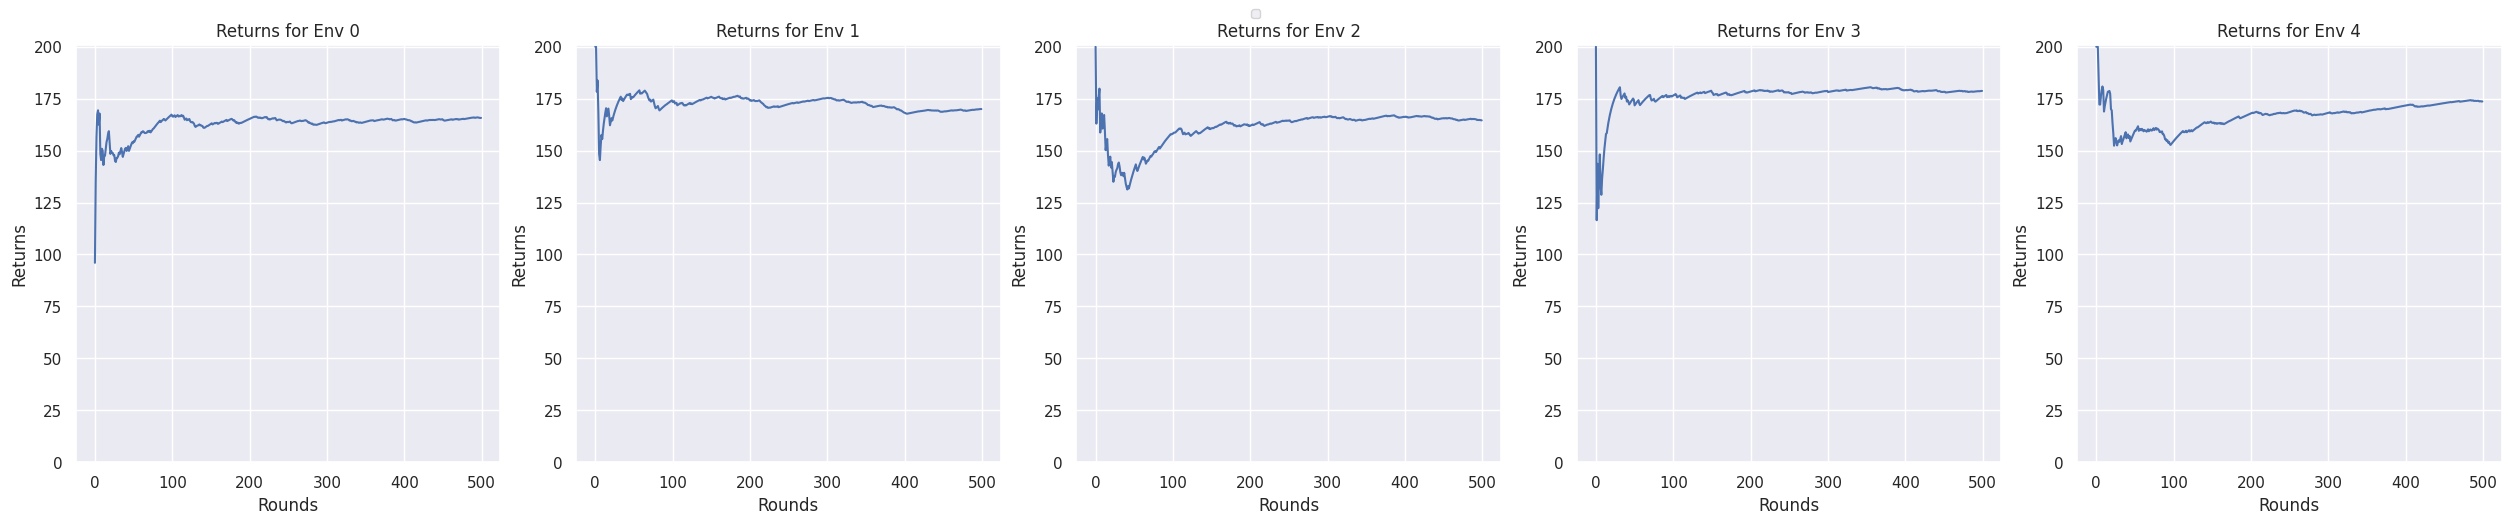

In [6]:

(num_envs, num_eps) = data["episode_lengths"].shape
xrange = range(num_eps)

num_cols = 5
num_rows = int(np.ceil(num_envs / 5))

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(5 * num_cols, 5 * num_rows),
    layout="constrained",
)

try:
    axes = axes.flatten()
except:
    axes = [axes]

for env_i in range(num_envs):
    axes[env_i].set_title(f"Returns for Env {env_i}")
    axes[env_i].set_xlabel("Rounds")
    axes[env_i].set_ylabel("Returns")

    xrange = np.arange(len(data["episode_returns"][env_i]))
    # axes[env_i].plot(xrange, data["episode_returns"][env_i])
    axes[env_i].plot(xrange, np.cumsum(data["episode_returns"][env_i]) / (xrange + 1))
    axes[env_i].set_ylim(0.0, 201.0)

fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=5,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8", 
)
fig.show()

In [7]:
print(data["action_counts"])

[[41403. 41475.]
 [42497. 42505.]
 [41114. 41167.]
 [44674. 44697.]
 [43424. 43414.]]


In [8]:
print(np.argmax(data["env_params"], axis=-1))

0


In [9]:
data["env_params"]

array(EnvParams(max_steps_in_episode=Array([200, 200, 200, 200, 200], dtype=int32, weak_type=True), gravity=Array([0.9793408 , 0.67499375, 0.87687135, 0.16762936, 0.71315336],      dtype=float32), masscart=Array([1., 1., 1., 1., 1.], dtype=float32, weak_type=True), masspole=Array([0.1, 0.1, 0.1, 0.1, 0.1], dtype=float32, weak_type=True), total_mass=Array([1.1, 1.1, 1.1, 1.1, 1.1], dtype=float32, weak_type=True), length=Array([0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32, weak_type=True), polemass_length=Array([0.05, 0.05, 0.05, 0.05, 0.05], dtype=float32, weak_type=True), force_mag=Array([10., 10., 10., 10., 10.], dtype=float32, weak_type=True), tau=Array([0.02, 0.02, 0.02, 0.02, 0.02], dtype=float32, weak_type=True), theta_threshold_radians=Array([0.20943952, 0.20943952, 0.20943952, 0.20943952, 0.20943952],      dtype=float32, weak_type=True), x_threshold=Array([2.4, 2.4, 2.4, 2.4, 2.4], dtype=float32, weak_type=True)),
      dtype=object)